# Customer Churn Exploratory Data Analysis

This notebook explores customer behaviour within a telecom subscription dataset to understand the primary factors associated with customer churn. The objective is to identify meaningful business patterns, assess data quality, and motivate the feature engineering and modelling choices developed in the following notebooks.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go

from IPython.display import display

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv(r"C:\Users\olive\Documents\workspace\Customer-Churn-Risk-Assessment-and-Retention-Analytics\data\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print(f"Number of customers : {df.shape[0]:,}")
print(f"Number of features  : {df.shape[1]}")
df.info()

Number of customers : 7,043
Number of features  : 21
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


### Initial observations

- Dataset contains 7043 customer records.
- The target variable is **Churn**.
- The dataset includes both numerical and categorical features describing customer demographics, subscription details and billing behaviour.

##  Can we trust the data?

In [5]:
missing = (
    df.isnull()
      .sum()
      .reset_index()
)

missing.columns = ["Feature","Missing"]

missing["Percent"] = (
    missing["Missing"] /
    len(df) *
    100
)

missing.sort_values(
    "Percent",
    ascending=False,
    inplace=True
)

missing

,Feature,Missing,Percent
0,customerID,0,0.0
1,gender,0,0.0
2,SeniorCitizen,0,0.0
3,Partner,0,0.0
4,Dependents,0,0.0
5,tenure,0,0.0
6,PhoneService,0,0.0
7,MultipleLines,0,0.0
8,InternetService,0,0.0
9,OnlineSecurity,0,0.0


In [6]:
duplicates = df.duplicated().sum()

print(
    f"Duplicate rows: {duplicates}"
)

Duplicate rows: 0


In [7]:
df.dtypes.value_counts()

str        18
int64       2
float64     1
Name: count, dtype: int64

In [8]:
pd.DataFrame({
    "Unique values":
    df.nunique()
})

,Unique values
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


### Handling `TotalCharges`

The `TotalCharges` column was stored as a string because a small number of newly acquired customers had blank values. These customers have zero tenure and therefore no accumulated charges. Since the missing values represent the absence of billing history rather than missing information, they were replaced with 0 before modelling.

In [9]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
).fillna(0)

df["TotalCharges"].isna().sum()

np.int64(0)

Data Processing Note: The TotalCharges feature was stored as text due to a small number of blank values associated with newly acquired customers (tenure = 0). These values were converted to numeric and replaced with zero, reflecting the absence of historical charges rather than missing information.

### Data Quality Summary

The dataset contains a mixture of numerical and categorical variables. 
There is no Missing values, duplicate records in the dataset.

## Distribution of Churn

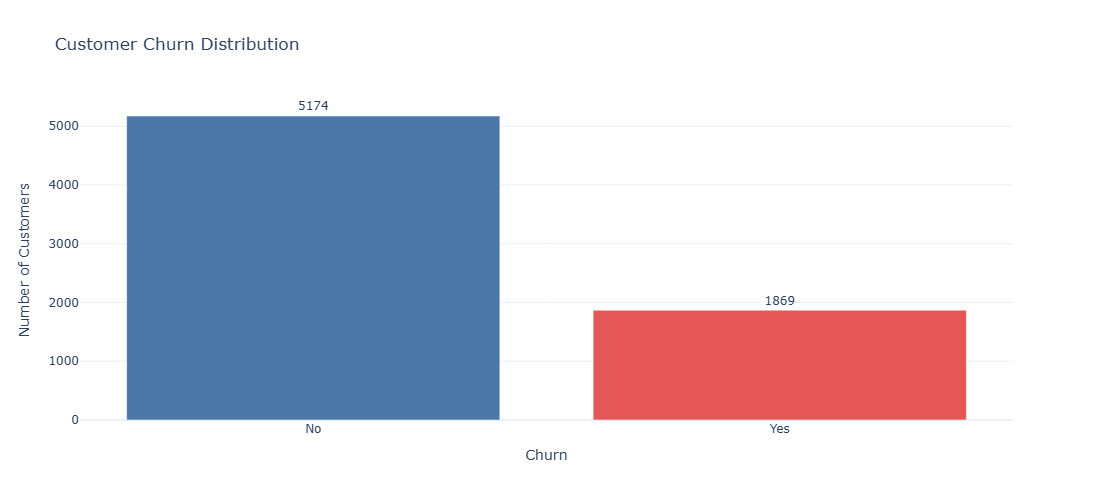

In [10]:
churn_counts = (
    df["Churn"]
    .value_counts()
    .rename_axis("Churn")
    .reset_index(name="Count")
)

fig = px.bar(
    churn_counts,
    x="Churn",
    y="Count",
    text="Count",
    color="Churn",
    title="Customer Churn Distribution",
    color_discrete_sequence=["#4C78A8", "#E45756"]
)

fig.update_traces(textposition="outside")

fig.update_layout(
    template="plotly_white",
    width=700,
    height=500,
    showlegend=False,
    yaxis_title="Number of Customers"
)

fig.show()

In [11]:
churn_percentage = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(churn_percentage)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

### Business Interpretation

The dataset exhibits class imbalance, with the majority of customers remaining subscribed while a smaller proportion churn. This imbalance has important implications for model evaluation. A model that predicts every customer as "non-churn" would achieve high accuracy while failing to identify customers at risk of leaving.

Consequently, this project emphasizes Precision, Recall, F1-score, ROC-AUC and Precision–Recall AUC rather than relying solely on classification accuracy.

## Customer Profile Analysis

### Does contract type influence Churn?

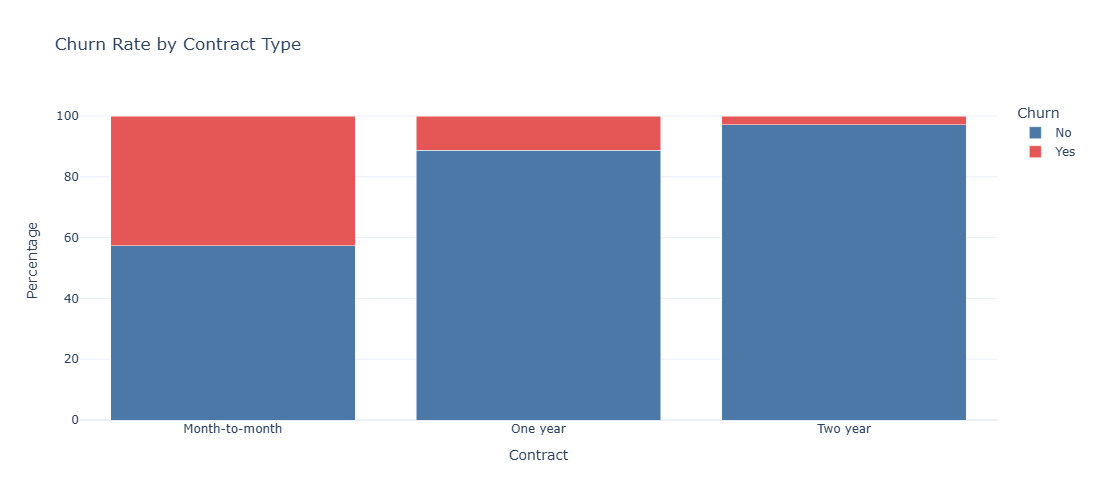

In [12]:
contract = (
    pd.crosstab(
        df["Contract"],
        df["Churn"],
        normalize="index"
    ) * 100
).reset_index()

contract = contract.melt(
    id_vars="Contract",
    var_name="Churn",
    value_name="Percentage"
)

fig = px.bar(
    contract,
    x="Contract",
    y="Percentage",
    color="Churn",
    barmode="stack",
    title="Churn Rate by Contract Type",
    color_discrete_sequence=["#4C78A8", "#E45756"]
)

fig.update_layout(
    template="plotly_white",
    width=900,
    height=500
)

fig.show()

- Customers on month-to-month contracts exhibit substantially higher churn rates than customers on one-year or two-year contracts. 
- Longer contractual commitments appear to improve customer retention, suggesting contract duration is one of the strongest predictors of churn.

### Does tenure influence churn?

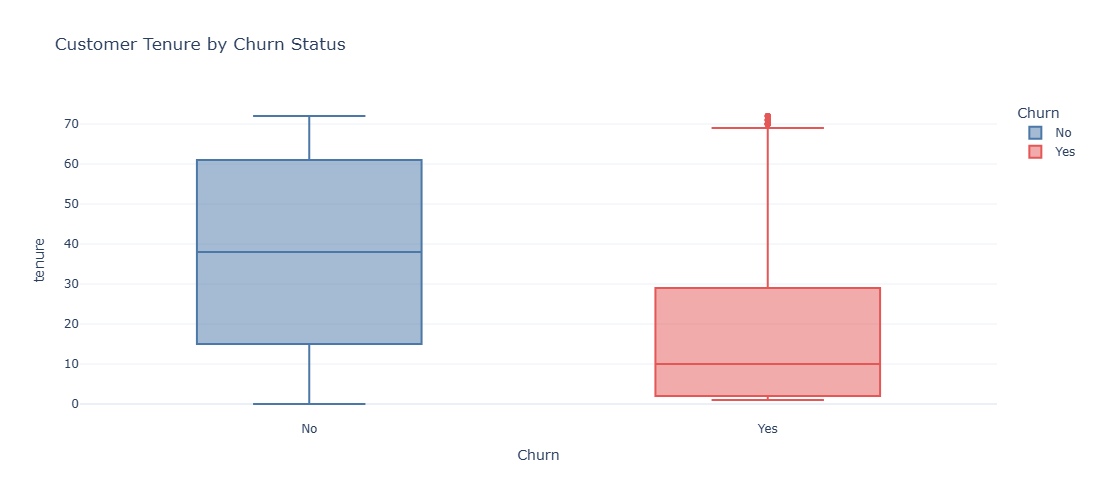

In [13]:
fig = px.box(
    df,
    x="Churn",
    y="tenure",
    color="Churn",
    title="Customer Tenure by Churn Status",
    color_discrete_sequence=["#4C78A8", "#E45756"]
)

fig.update_layout(
    template="plotly_white",
    width=800,
    height=500
)

fig.show()

- Customers who churn typically have much shorter tenures than retained customers. 

This indicates that customer attrition is concentrated during the early stages of the customer lifecycle, highlighting the importance of onboarding and early engagement strategies.

### Do monthly charges influence churn?

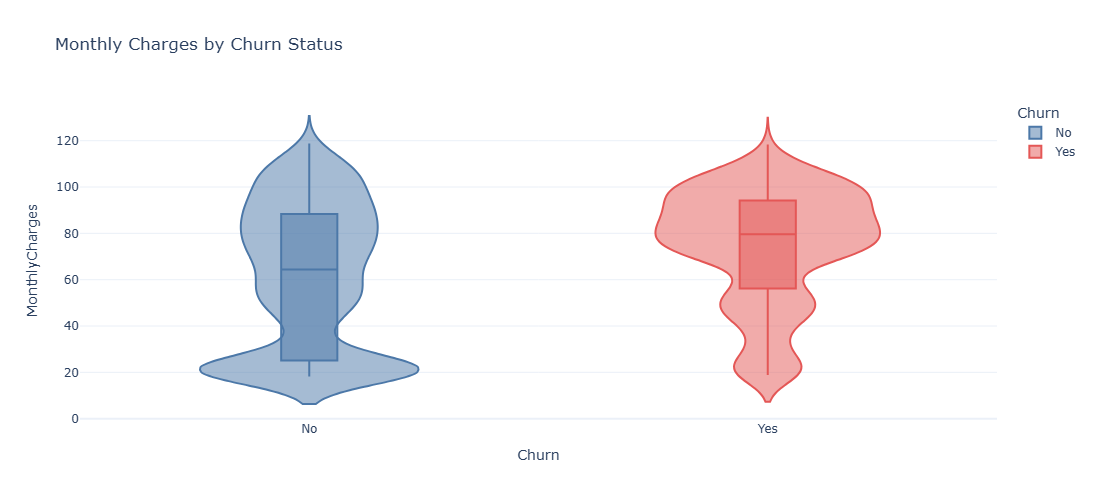

In [14]:
fig = px.violin(
    df,
    x="Churn",
    y="MonthlyCharges",
    color="Churn",
    box=True,
    title="Monthly Charges by Churn Status",
    color_discrete_sequence=["#4C78A8", "#E45756"]
)

fig.update_layout(
    template="plotly_white",
    width=800,
    height=500
)

fig.show()

- Customers who churn tend to have higher monthly charges than those who remain.

Higher subscription costs may increase churn risk, particularly when customers perceive limited value relative to price.

## Customer Demographics

### Does gender influence churn?

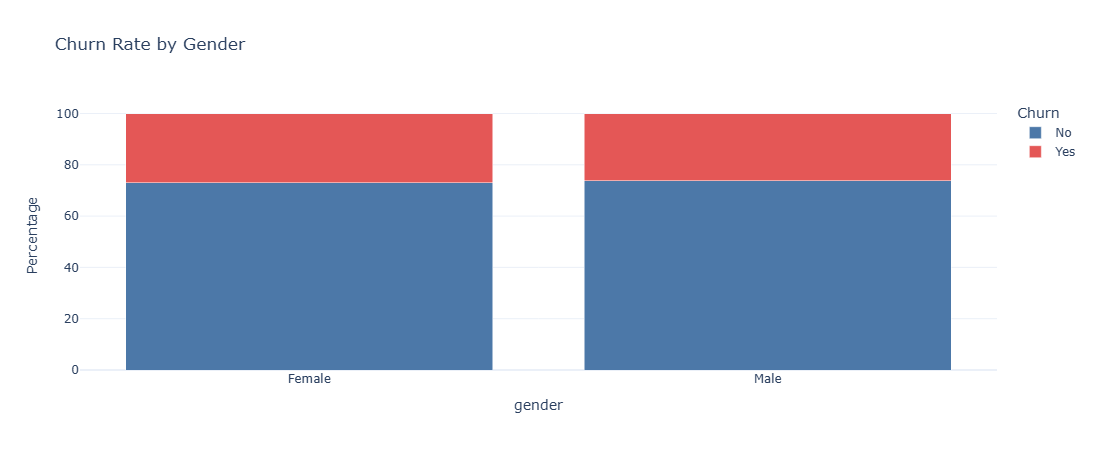

In [15]:
gender_churn = (
    pd.crosstab(
        df["gender"],
        df["Churn"],
        normalize="index"
    ) * 100
).reset_index()

gender_churn = gender_churn.melt(
    id_vars="gender",
    var_name="Churn",
    value_name="Percentage"
)

fig = px.bar(
    gender_churn,
    x="gender",
    y="Percentage",
    color="Churn",
    barmode="stack",
    title="Churn Rate by Gender",
    color_discrete_sequence=["#4C78A8", "#E45756"]
)

fig.update_layout(
    template="plotly_white",
    height=450
)

fig.show()

Churn rates are very similar across genders, suggesting that gender alone is not a meaningful predictor of customer attrition. This indicates that demographic characteristics may contribute less to churn than behavioural or service-related factors.

### Are senior citizens more likely to churn?

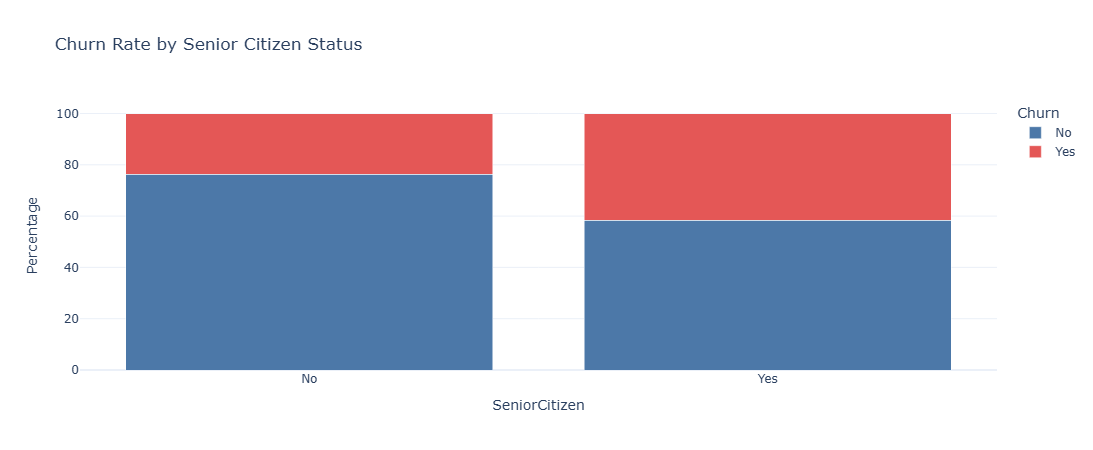

In [16]:
senior = (
    pd.crosstab(
        df["SeniorCitizen"],
        df["Churn"],
        normalize="index"
    ) * 100
).reset_index()

senior["SeniorCitizen"] = senior["SeniorCitizen"].map({
    0:"No",
    1:"Yes"
})

senior = senior.melt(
    id_vars="SeniorCitizen",
    var_name="Churn",
    value_name="Percentage"
)

fig = px.bar(
    senior,
    x="SeniorCitizen",
    y="Percentage",
    color="Churn",
    barmode="stack",
    title="Churn Rate by Senior Citizen Status",
    color_discrete_sequence=["#4C78A8", "#E45756"]
)

fig.update_layout(
    template="plotly_white",
    height=450
)

fig.show()

Churn rates are a bit higher for senior citizens.

### Does having dependents reduce churn?

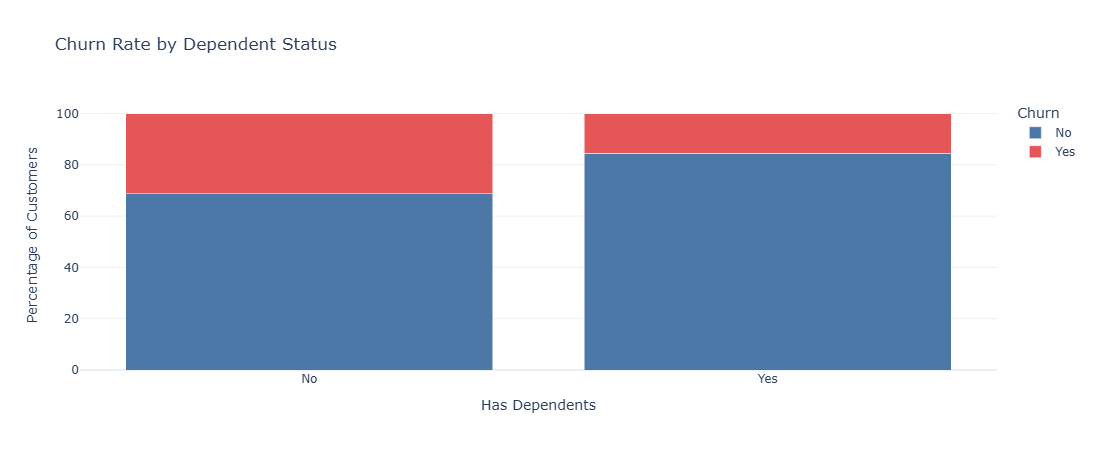

In [17]:
dependents = (
    pd.crosstab(
        df["Dependents"],
        df["Churn"],
        normalize="index"
    ) * 100
).reset_index()

dependents = dependents.melt(
    id_vars="Dependents",
    var_name="Churn",
    value_name="Percentage"
)

fig = px.bar(
    dependents,
    x="Dependents",
    y="Percentage",
    color="Churn",
    barmode="stack",
    title="Churn Rate by Dependent Status",
    color_discrete_sequence=["#4C78A8", "#E45756"]
)

fig.update_layout(
    template="plotly_white",
    width=800,
    height=450,
    xaxis_title="Has Dependents",
    yaxis_title="Percentage of Customers"
)

fig.show()

In [18]:
dependents_rate = (
    df.groupby("Dependents")["Churn"]
      .value_counts(normalize=True)
      .rename("Rate")
      .mul(100)
      .reset_index()
)

dependents_rate

,Dependents,Churn,Rate
0,No,No,68.720860
1,No,Yes,31.279140
2,Yes,No,84.549763
3,Yes,Yes,15.450237


Customers with dependents exhibit substantially lower churn rates than customers without dependents. This suggests that customers with greater household commitments may maintain longer-term service relationships and be less likely to switch providers. Dependent status therefore appears to be a meaningful predictor of customer retention.

In [19]:
overall = (
    df["Churn"]
      .eq("Yes")
      .mean() * 100
)

dep_yes = (
    df.loc[df["Dependents"]=="Yes","Churn"]
      .eq("Yes")
      .mean() * 100
)

dep_no = (
    df.loc[df["Dependents"]=="No","Churn"]
      .eq("Yes")
      .mean() * 100
)

print(f"Overall churn: {overall:.1f}%")
print(f"Dependents = Yes : {dep_yes:.1f}%")
print(f"Dependents = No  : {dep_no:.1f}%")

Overall churn: 26.5%
Dependents = Yes : 15.5%
Dependents = No  : 31.3%


## 📌 Customer Profile Insights

| Feature | Key Observation | Business Insight | Priority |
|----------|-----------------|------------------|:--------:|
| Gender | Similar churn rates across genders | Gender is not a strong predictor of churn | ⭐ |
| Senior Citizen |  |  | ⭐⭐ |
| Partner |  |  | ⭐⭐ |
| Dependents |  |  | ⭐⭐⭐ |
| Tenure |  |  | ⭐⭐⭐⭐ |
| Monthly Charges |  |  | ⭐⭐⭐ |

## Service Usage Analysis

In [20]:
import plotly.express as px
import pandas as pd

def plot_categorical_churn(df, feature):
    """
    Plot churn percentage by categorical feature.
    """

    summary = (
        pd.crosstab(
            df[feature],
            df["Churn"],
            normalize="index"
        ) * 100
    ).reset_index()

    summary = summary.melt(
        id_vars=feature,
        var_name="Churn",
        value_name="Percentage"
    )

    fig = px.bar(
        summary,
        x=feature,
        y="Percentage",
        color="Churn",
        barmode="stack",
        text=summary["Percentage"].round(1),
        color_discrete_sequence=["#4C78A8", "#E45756"],
        title=f"Churn Rate by {feature}"
    )

    fig.update_traces(textposition="inside")

    fig.update_layout(
        template="plotly_white",
        width=900,
        height=500,
        xaxis_title=feature,
        yaxis_title="Percentage of Customers",
        legend_title=""
    )

    fig.show()

    churn_rate = (
        df.groupby(feature)["Churn"]
          .apply(lambda x: (x == "Yes").mean() * 100)
          .sort_values(ascending=False)
          .round(2)
    )

    display(churn_rate)

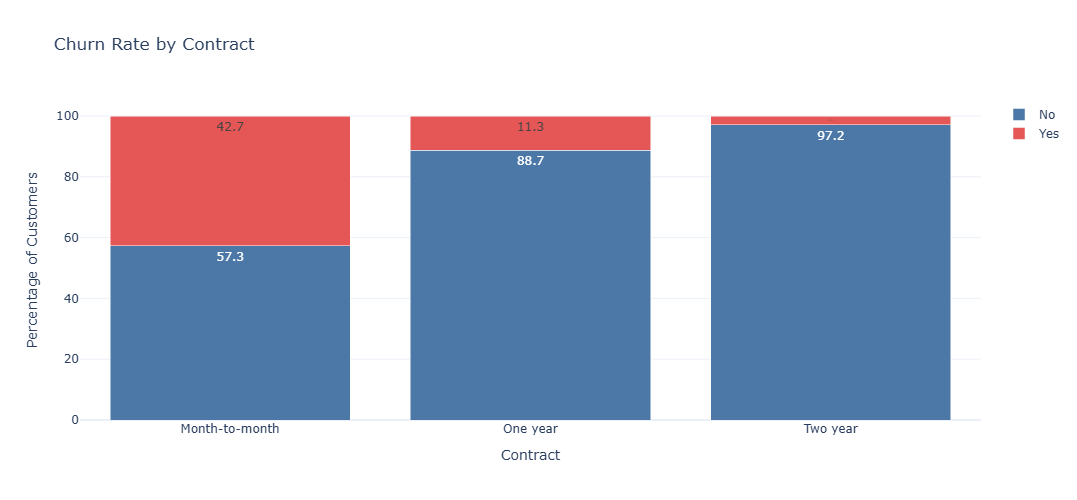

Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64

In [21]:
plot_categorical_churn(df, "Contract")

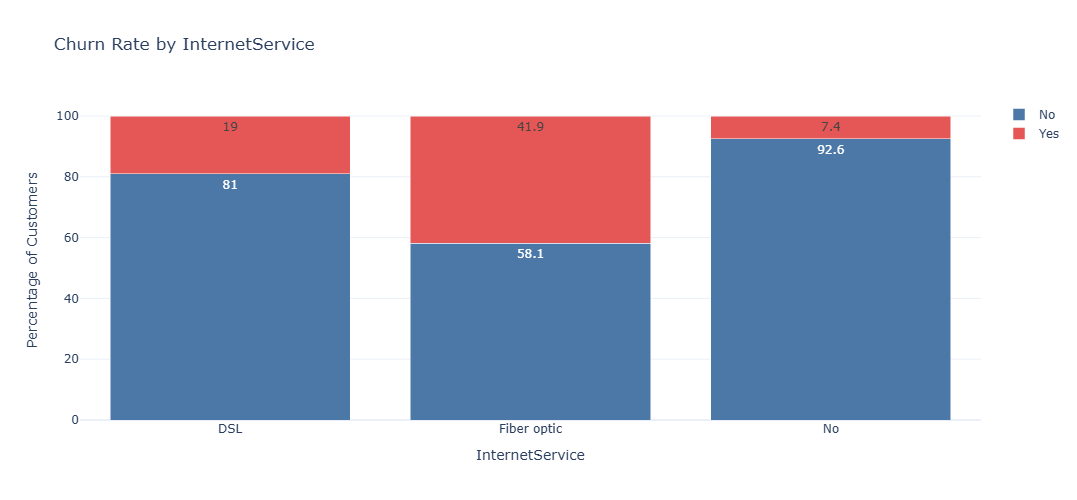

InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Churn, dtype: float64

In [22]:
plot_categorical_churn(df, "InternetService")

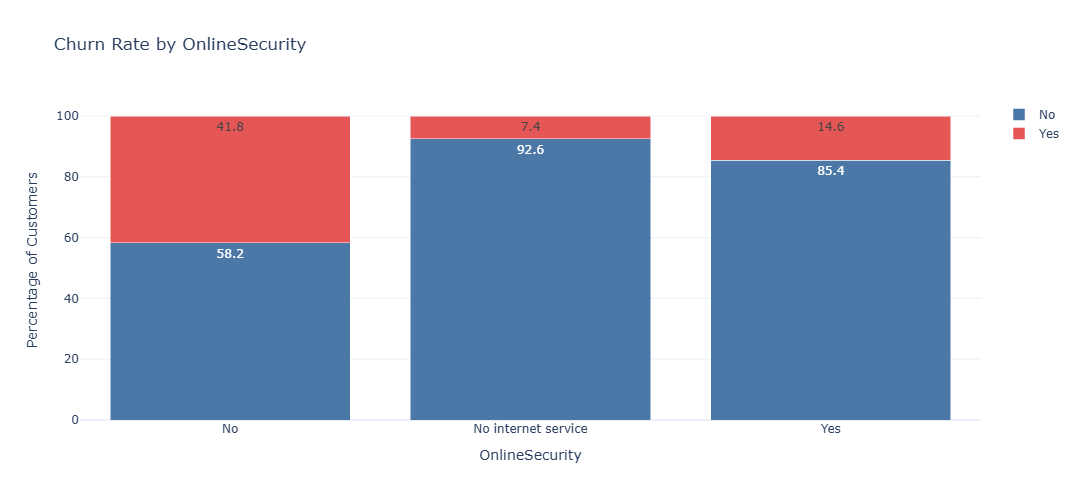

OnlineSecurity
No                     41.77
Yes                    14.61
No internet service     7.40
Name: Churn, dtype: float64

In [23]:
plot_categorical_churn(df, "OnlineSecurity")

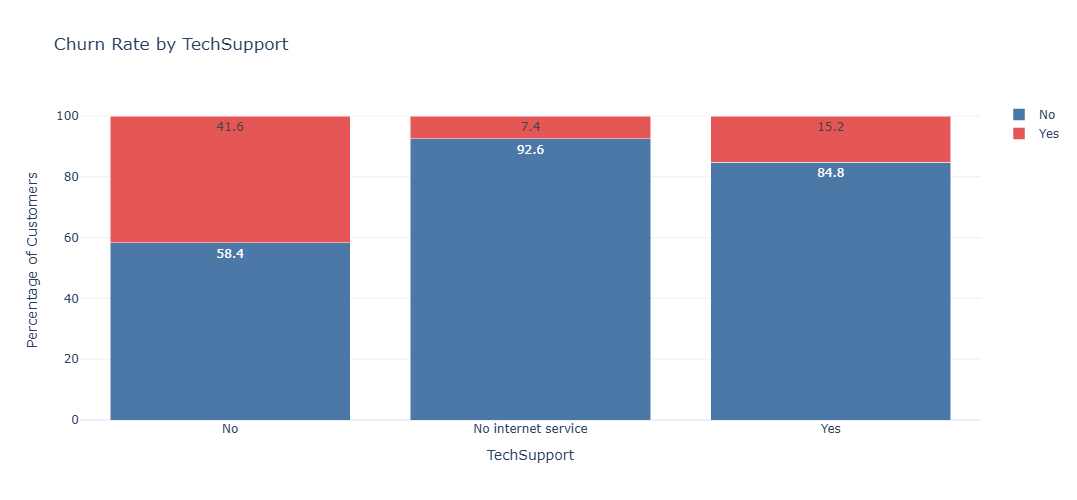

TechSupport
No                     41.64
Yes                    15.17
No internet service     7.40
Name: Churn, dtype: float64

In [24]:
plot_categorical_churn(df, "TechSupport")

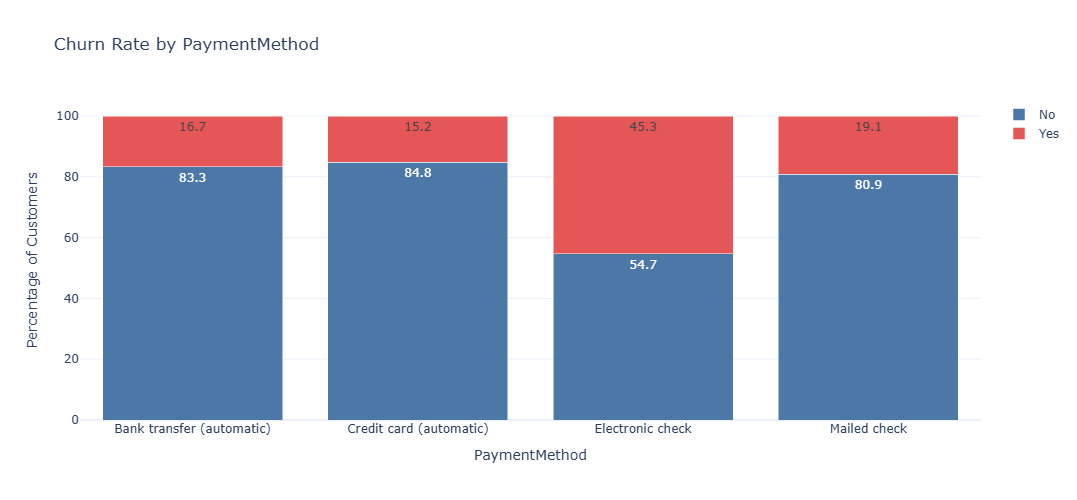

PaymentMethod
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: Churn, dtype: float64

In [25]:
plot_categorical_churn(df, "PaymentMethod")

## 📌 Service Usage Insights

The following table summarizes the key findings from the service usage analysis and highlights customer segments associated with the highest churn risk.

| Feature | Highest-Risk Segment | Churn Rate | Business Insight | Priority |
|----------|----------------------|-----------:|------------------|:--------:|
| Contract |  |  |  | ⭐⭐⭐⭐⭐ |
| Internet Service |  |  |  | ⭐⭐⭐⭐ |
| Online Security |  |  |  | ⭐⭐⭐⭐ |
| Tech Support |  |  |  | ⭐⭐⭐⭐ |
| Online Backup |  |  |  | ⭐⭐⭐ |
| Device Protection |  |  |  | ⭐⭐⭐ |
| Streaming TV |  |  |  | ⭐⭐ |
| Streaming Movies |  |  |  | ⭐⭐ |
| Payment Method |  |  |  | ⭐⭐⭐ |

## Numerical Feature Analysis

### Do customers who churn have shorter tenure?

In [26]:
def plot_numeric_churn(df, feature):

    fig = px.violin(
        df,
        x="Churn",
        y=feature,
        color="Churn",
        box=True,
        points=False,
        color_discrete_sequence=["#4C78A8", "#E45756"],
        title=f"{feature} Distribution by Churn Status"
    )

    fig.update_layout(
        template="plotly_white",
        width=850,
        height=500,
        showlegend=False
    )

    fig.show()

    display(
        df.groupby("Churn")[feature]
          .describe()
          .round(2)
    )

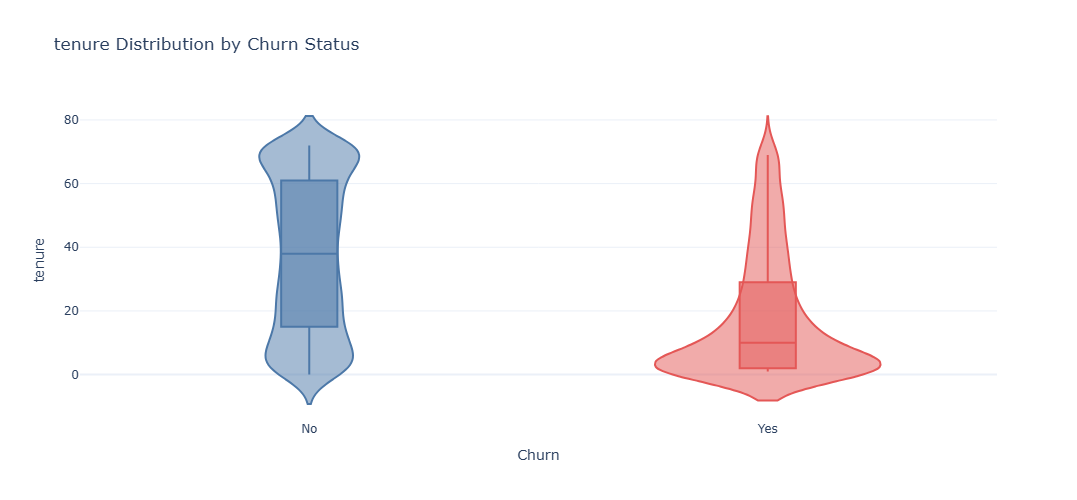

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.57,24.11,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.98,19.53,1.0,2.0,10.0,29.0,72.0


In [27]:
plot_numeric_churn(df, "tenure")

- Customers who churn generally have substantially shorter tenures than retained customers.
- This suggests that customer attrition is concentrated during the early stages of the customer lifecycle, highlighting onboarding and early engagement as key retention opportunities.

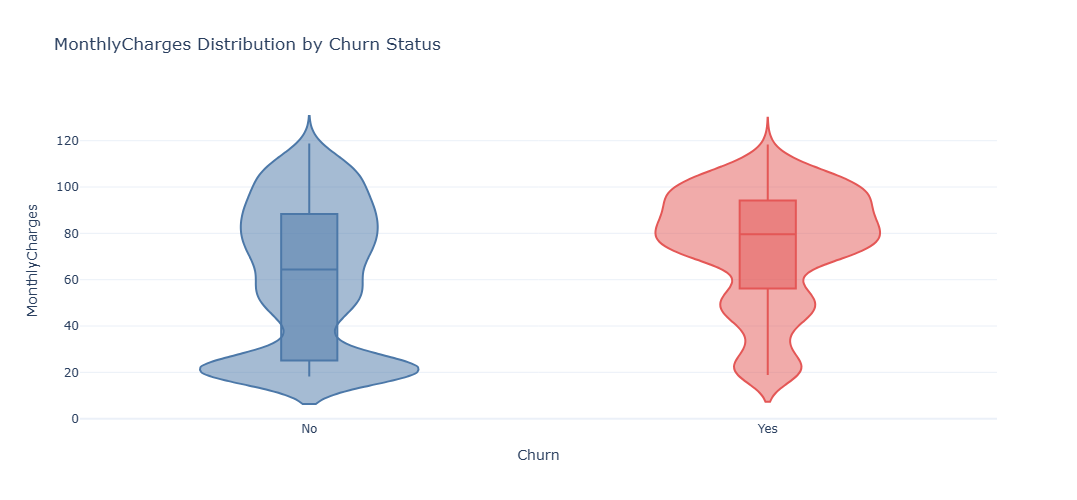

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.27,31.09,18.25,25.10,64.43,88.4,118.75
Yes,1869.0,74.44,24.67,18.85,56.15,79.65,94.2,118.35


In [28]:
plot_numeric_churn(df, "MonthlyCharges")

- Churning customers typically incur higher monthly charges than retained customers.
- While premium services may generate higher revenue, they may also increase churn risk if customers perceive insufficient value.

### Handling `TotalCharges`

The `TotalCharges` column was stored as a string because a small number of newly acquired customers had blank values. These customers have zero tenure and therefore no accumulated charges. Since the missing values represent the absence of billing history rather than missing information, they were replaced with 0 before modelling.

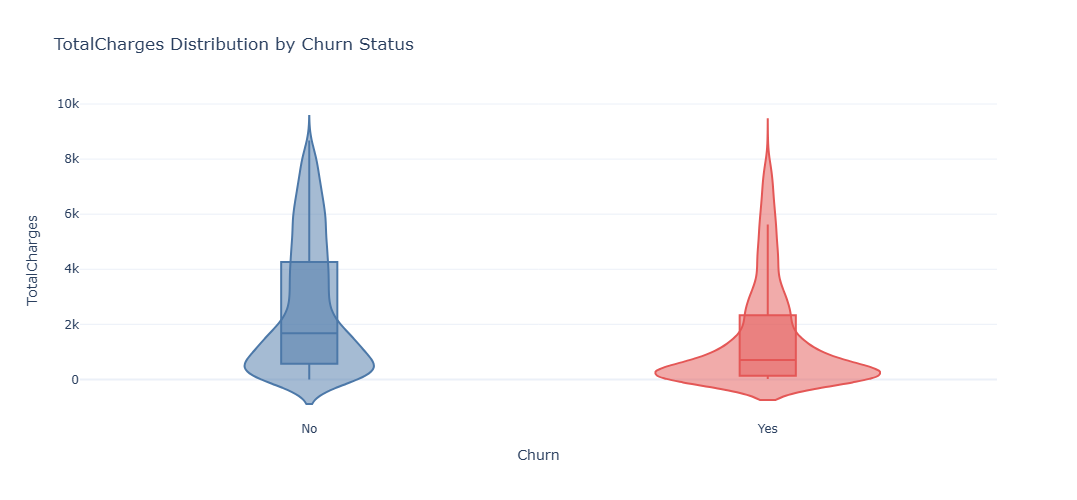

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,2549.91,2329.95,0.00,572.9,1679.52,4262.85,8672.45
Yes,1869.0,1531.80,1890.82,18.85,134.5,703.55,2331.30,8684.80


In [29]:
plot_numeric_churn(df, "TotalCharges")

## 📌 Numerical Feature Insights

| Feature | Observation | Business Insight | Priority |
|----------|-------------|------------------|:--------:|
| Tenure | Churners have significantly shorter tenure | Early customer lifecycle is the highest-risk period | ⭐⭐⭐⭐⭐ |
| Monthly Charges | Churners tend to pay higher monthly fees | Pricing influences retention | ⭐⭐⭐⭐ |
| Total Charges | Higher for retained customers | Reflects tenure rather than direct churn risk | ⭐⭐⭐ |

## Correlation Analysis

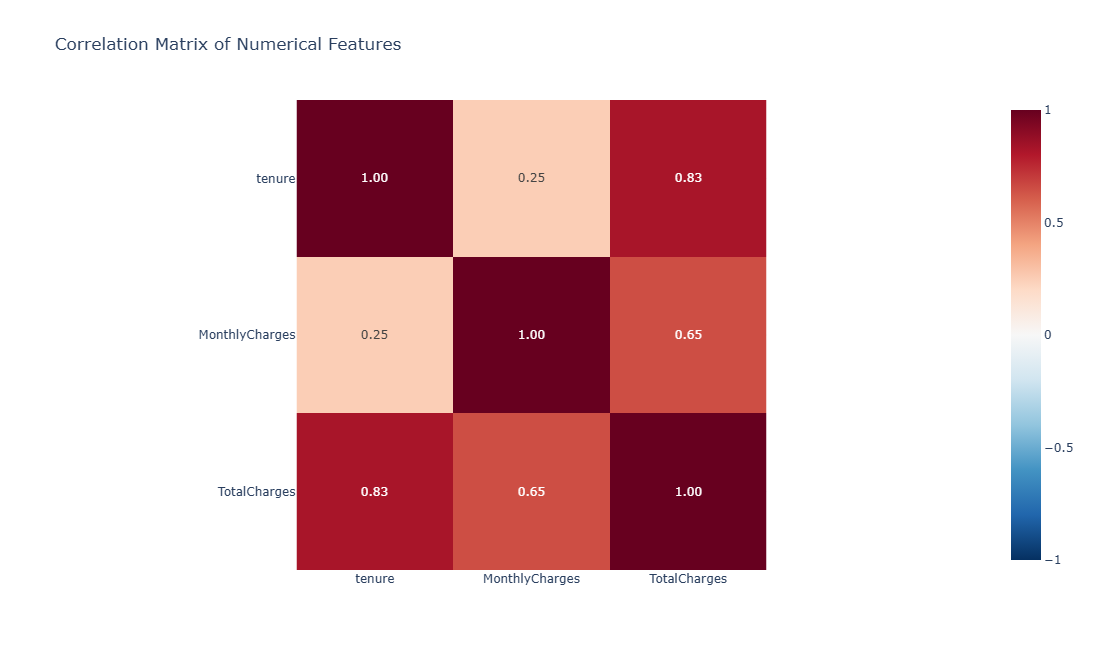

In [30]:
numeric = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

corr = df[numeric].corr()

fig = px.imshow(
    corr,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    title="Correlation Matrix of Numerical Features"
)

fig.update_layout(
    template="plotly_white",
    width=700,
    height=650
)

fig.show()

# 📌 Exploratory Data Analysis Summary

The exploratory analysis identified several customer characteristics strongly associated with churn.

### Key findings

- Contract type is the strongest categorical indicator of churn.
- Customers with shorter tenure exhibit substantially higher churn rates.
- Customers subscribed to Tech Support and Online Security services are more likely to remain.
- Higher monthly charges are associated with increased churn risk.
- Gender has minimal influence on customer churn.

These findings directly informed the subsequent feature engineering and model development stages by highlighting the variables most likely to contribute predictive value.